## 1. Setup & Imports

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import SGD

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.15.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Set seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"✅ Random seed set to {SEED}")

✅ Random seed set to 42


## 2. Configuration

In [3]:
# ============================================
# CONFIGURATION (Official Keras Style)
# ============================================

DATASET_NAME = 'MangoLeafBD'
MODEL_NAME = 'ResNet50_Simple'

# Official ResNet50 settings
IMG_SIZE = 224  # Official ResNet50 input size
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

# Paths
WORKSPACE_DIR = Path('/Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook')
DATA_DIR = WORKSPACE_DIR / 'datasets' / DATASET_NAME / 'processed'
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

# Output directories
EXPERIMENTS_BASE = WORKSPACE_DIR / DATASET_NAME / 'experiments' / MODEL_NAME
OUTPUTS_BASE = WORKSPACE_DIR / DATASET_NAME / 'outputs' / MODEL_NAME

def get_next_run_dir(parent_dir, prefix='run_'):
    parent_dir = Path(parent_dir)
    parent_dir.mkdir(parents=True, exist_ok=True)
    existing = [d for d in parent_dir.iterdir() if d.is_dir() and d.name.startswith(prefix)]
    nums = [int(d.name[len(prefix):]) for d in existing if d.name[len(prefix):].isdigit()]
    next_num = max(nums) + 1 if nums else 1
    return parent_dir / f'{prefix}{next_num}'

EXPERIMENT_DIR = get_next_run_dir(EXPERIMENTS_BASE)
OUTPUT_DIR = get_next_run_dir(OUTPUTS_BASE)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("📁 CONFIGURATION")
print("="*60)
print(f"Dataset        : {DATASET_NAME}")
print(f"Model          : {MODEL_NAME}")
print(f"Input Size     : {IMG_SIZE}×{IMG_SIZE}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Epochs         : {EPOCHS}")
print(f"Preprocessing  : ImageNet normalization (mean/std)")
print(f"Optimizer      : SGD (lr={LEARNING_RATE}, momentum=0.9)")
print(f"Experiment Dir : {EXPERIMENT_DIR}")
print(f"Output Dir     : {OUTPUT_DIR}")
print("="*60)

📁 CONFIGURATION
Dataset        : MangoLeafBD
Model          : ResNet50_Simple
Input Size     : 224×224
Batch Size     : 32
Epochs         : 100
Preprocessing  : ImageNet normalization (mean/std)
Optimizer      : SGD (lr=0.001, momentum=0.9)
Experiment Dir : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15
Output Dir     : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/outputs/ResNet50_Simple/run_15


## 3. Data Loading

Using ImageNet normalization (mean subtraction + std division) which ResNet50 expects.

In [4]:
# ============================================
# DATA GENERATORS
# ============================================
# ImageNet normalization (what ResNet50 expects)
# Step 1: Scale to [0,1], Step 2: Normalize with ImageNet mean/std

# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def imagenet_preprocess(image):
    """Normalize image using ImageNet mean and std"""
    image = image / 255.0  # Scale to [0, 1]
    image = (image - IMAGENET_MEAN) / IMAGENET_STD  # Normalize
    return image

# Training with LIGHT augmentation (reduced to prevent underfitting)
train_datagen = ImageDataGenerator(
    preprocessing_function=imagenet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test - only normalize, no augmentation
val_test_datagen = ImageDataGenerator(
    preprocessing_function=imagenet_preprocess
)

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

n_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print(f"\n✅ Data loaded successfully!")
print(f"   Classes: {n_classes}")
print(f"   Training: {train_generator.samples} images")
print(f"   Validation: {val_generator.samples} images")
print(f"   Test: {test_generator.samples} images")

# Save class names
with open(EXPERIMENT_DIR / 'classes.json', 'w') as f:
    json.dump(class_names, f, indent=2)

Found 3200 images belonging to 8 classes.
Found 400 images belonging to 8 classes.
Found 400 images belonging to 8 classes.

✅ Data loaded successfully!
   Classes: 8
   Training: 3200 images
   Validation: 400 images
   Test: 400 images
Found 400 images belonging to 8 classes.
Found 400 images belonging to 8 classes.

✅ Data loaded successfully!
   Classes: 8
   Training: 3200 images
   Validation: 400 images
   Test: 400 images


## 4. Build Model

Following official Keras transfer learning guide:
1. Load ResNet50 with ImageNet weights (without top)
2. Freeze the base model
3. Add simple classification head

In [5]:
# ============================================
# BUILD MODEL WITH FINE-TUNING
# ============================================
# Reference: https://keras.io/guides/transfer_learning/

# 1. Load base model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 2. Freeze all layers initially
base_model.trainable = False

# 3. Build model with simple head
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='ResNet50_FineTuned')

print(f"\n✅ Model built successfully!")
print(f"   Base model: ResNet50")
print(f"   Total params: {model.count_params():,}")
print(f"   Trainable params (before unfreezing): {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}")

# 4. Unfreeze top layers for fine-tuning
# ResNet50 has 5 main blocks (conv2_x to conv5_x)
# Unfreeze conv5_x block (last 38 layers)
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 38

# Freeze all layers before fine_tune_at
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"\n🔓 Fine-tuning enabled:")
print(f"   Total layers in base: {len(base_model.layers)}")
print(f"   Frozen layers: {fine_tune_at}")
print(f"   Trainable layers: {len(base_model.layers) - fine_tune_at}")
print(f"   Trainable params (after unfreezing): {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}")

model.summary()

2025-11-29 03:27:30.078765: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-29 03:27:30.078798: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-29 03:27:30.078804: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-29 03:27:30.078828: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-29 03:27:30.078848: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



✅ Model built successfully!
   Base model: ResNet50
   Total params: 23,604,104
   Trainable params (before unfreezing): 16,392

🔓 Fine-tuning enabled:
   Total layers in base: 175
   Frozen layers: 137
   Trainable layers: 38
   Trainable params (after unfreezing): 15,258,120
Model: "ResNet50_FineTuned"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                 

## 5. Compile & Train

In [6]:
# ============================================
# COMPILE MODEL FOR FINE-TUNING
# ============================================
# Use lower learning rate for fine-tuning

FINE_TUNE_LR = LEARNING_RATE / 10  # 0.0001

optimizer = SGD(learning_rate=FINE_TUNE_LR, momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ Model compiled for fine-tuning")
print(f"   Optimizer: SGD (lr={FINE_TUNE_LR}, momentum=0.9)")
print(f"   Note: Lower LR for fine-tuning to avoid destroying pre-trained weights")

✅ Model compiled for fine-tuning
   Optimizer: SGD (lr=0.0001, momentum=0.9)
   Note: Lower LR for fine-tuning to avoid destroying pre-trained weights


In [7]:
# ============================================
# CALLBACKS
# ============================================

model_path = EXPERIMENT_DIR / f'{MODEL_NAME}_MangoLeafBD_best.h5'

callbacks = [
    ModelCheckpoint(
        filepath=str(model_path),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(EXPERIMENT_DIR / 'training_log.csv')
]

print("✅ Callbacks configured")

✅ Callbacks configured


In [8]:
# ============================================
# TRAIN MODEL
# ============================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING")
print("="*60)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")


🚀 STARTING TRAINING
Epoch 1/100
Epoch 1/100


2025-11-29 03:27:32.231491: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-11-29 03:27:32.315985: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


100/100 [==============================] - ETA: 0s - loss: 1.6898 - accuracy: 0.3594
Epoch 1: val_accuracy improved from -inf to 0.63000, saving model to /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15/ResNet50_Simple_MangoLeafBD_best.h5

Epoch 1: val_accuracy improved from -inf to 0.63000, saving model to /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15/ResNet50_Simple_MangoLeafBD_best.h5
100/100 [==============================] - 28s 263ms/step - loss: 1.6898 - accuracy: 0.3594 - val_loss: 1.0451 - val_accuracy: 0.6300
Epoch 2/100
100/100 [==============================] - 28s 263ms/step - loss: 1.6898 - accuracy: 0.3594 - val_loss: 1.0451 - val_accuracy: 0.6300
Epoch 2/100
100/100 [==============================] - ETA: 0s - loss: 0.9739 - accuracy: 0.6322
Epoch 2: val_accuracy improved from 0.63000 to 0.74750, saving model to /Users/invictus/Desktop

In [9]:
# Save training history
history_dict = {
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']]
}

with open(EXPERIMENT_DIR / 'history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f"✅ Training history saved to {EXPERIMENT_DIR / 'history.json'}")

✅ Training history saved to /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15/history.json


## 6. Evaluation

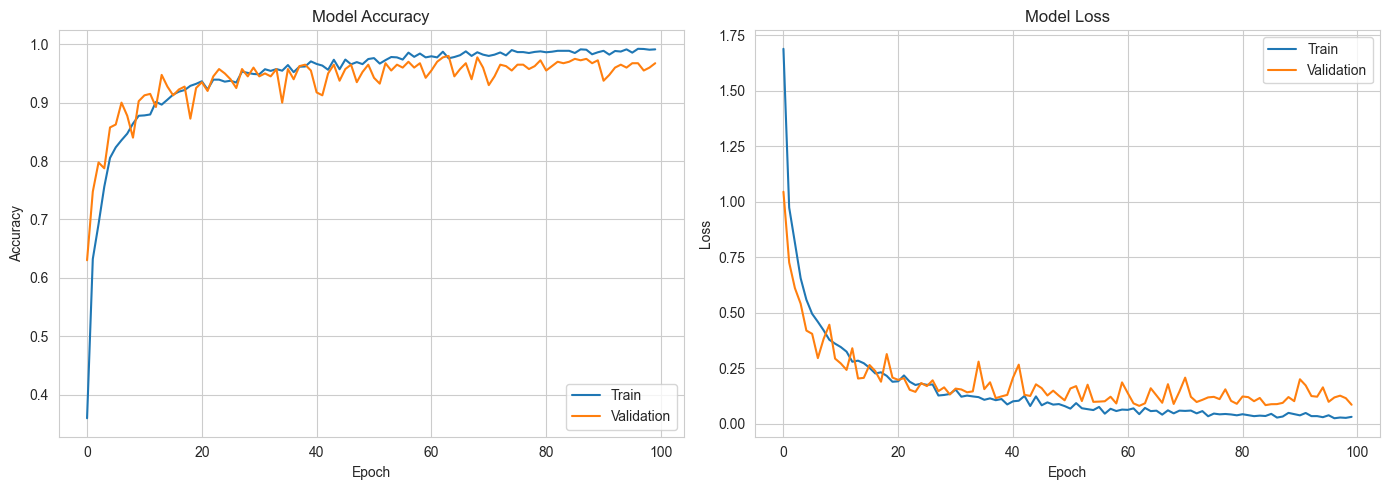

✅ Training history plot saved


In [10]:
# ============================================
# PLOT TRAINING HISTORY
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training history plot saved")

In [11]:
# ============================================
# EVALUATE ON TEST SET
# ============================================

print("\n" + "="*60)
print("📊 EVALUATING ON TEST SET")
print("="*60)

# Load best model
best_model = keras.models.load_model(str(model_path))

# Evaluate
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print(f"\n📈 Test Results:")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


📊 EVALUATING ON TEST SET


13/13 [==============================] - 3s 172ms/step - loss: 0.1394 - accuracy: 0.9600

📈 Test Results:
   Loss: 0.1394
   Accuracy: 0.9600 (96.00%)
13/13 [==============================] - 3s 172ms/step - loss: 0.1394 - accuracy: 0.9600

📈 Test Results:
   Loss: 0.1394
   Accuracy: 0.9600 (96.00%)


13/13 [==============================] - 3s 169ms/step

📋 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.9792    0.9400    0.9592        50
Bacterial Canker     0.9615    1.0000    0.9804        50
  Cutting Weevil     1.0000    1.0000    1.0000        50
        Die Back     1.0000    0.9600    0.9796        50
      Gall Midge     0.9216    0.9400    0.9307        50
         Healthy     0.9245    0.9800    0.9515        50
  Powdery Mildew     0.9423    0.9800    0.9608        50
     Sooty Mould     0.9565    0.8800    0.9167        50

        accuracy                         0.9600       400
       macro avg     0.9607    0.9600    0.9598       400
    weighted avg     0.9607    0.9600    0.9598       400


📋 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.9792    0.9400    0.9592        50
Bacterial Canker     0.9615    1.0000    0.9804        50
  Cutting Weevil     

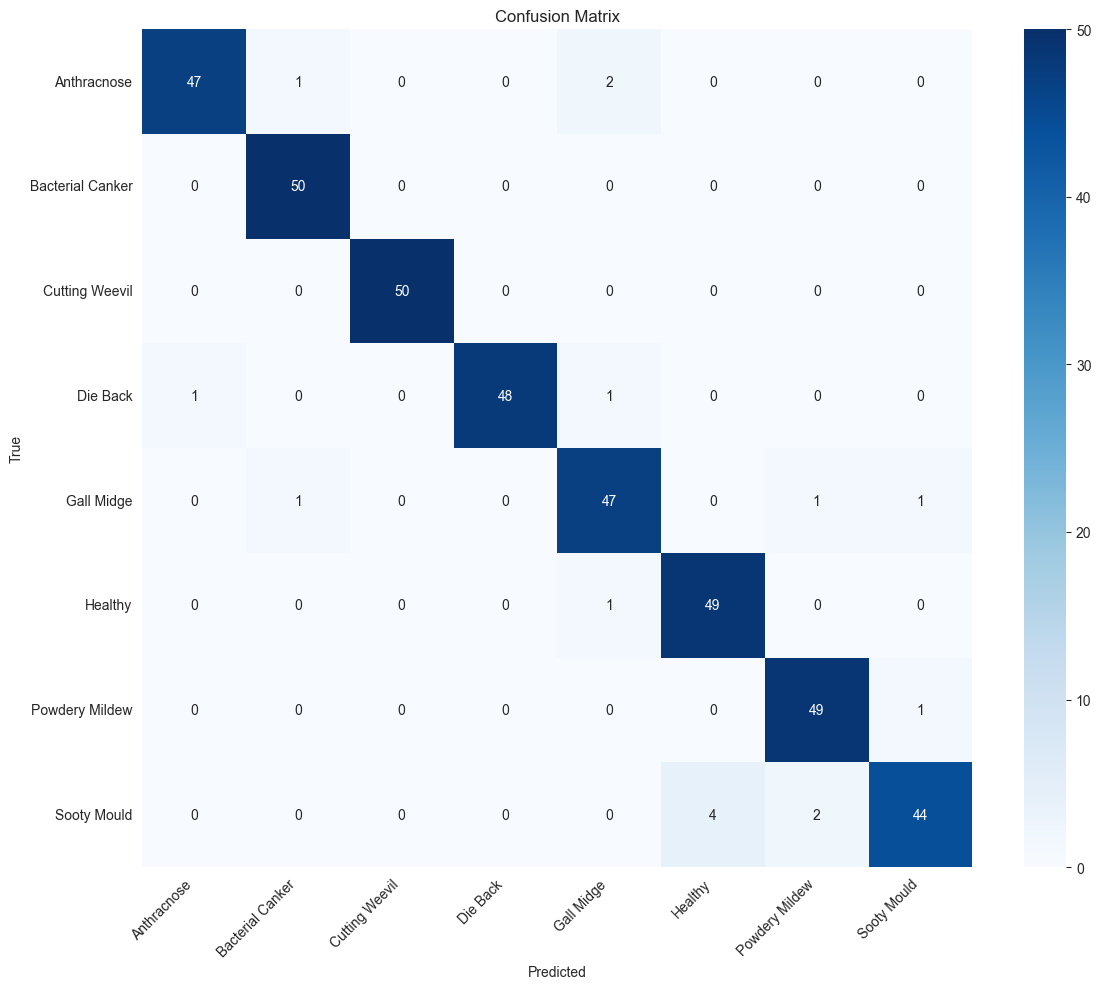


✅ Confusion matrix saved


In [12]:
# ============================================
# CLASSIFICATION REPORT & CONFUSION MATRIX
# ============================================

# Get predictions
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)
print(report)

# Save report
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Confusion matrix saved")

## 7. Summary

In [13]:
# ============================================
# FINAL SUMMARY
# ============================================

# Save model info
model_info = {
    'model_name': MODEL_NAME,
    'dataset': DATASET_NAME,
    'input_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(history.history['accuracy']),
    'optimizer': f'SGD (lr={LEARNING_RATE}, momentum=0.9)',
    'preprocessing': 'preprocess_input (official)',
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'total_params': model.count_params(),
    'n_classes': n_classes,
    'class_names': class_names
}

with open(EXPERIMENT_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("\n" + "="*60)
print("🏁 FINAL SUMMARY")
print("="*60)
print(f"Model          : {MODEL_NAME}")
print(f"Dataset        : {DATASET_NAME}")
print(f"Input Size     : {IMG_SIZE}×{IMG_SIZE}")
print(f"Preprocessing  : preprocess_input (official Keras)")
print(f"Optimizer      : SGD (lr={LEARNING_RATE})")
print(f"Epochs Trained : {len(history.history['accuracy'])}")
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss      : {test_loss:.4f}")
print("="*60)
print(f"✅ Model saved : {model_path}")
print(f"✅ History     : {EXPERIMENT_DIR / 'history.json'}")
print(f"✅ Model Info  : {EXPERIMENT_DIR / 'model_info.json'}")
print("="*60)
print("🎉 TRAINING COMPLETE!")


🏁 FINAL SUMMARY
Model          : ResNet50_Simple
Dataset        : MangoLeafBD
Input Size     : 224×224
Preprocessing  : preprocess_input (official Keras)
Optimizer      : SGD (lr=0.001)
Epochs Trained : 100
Test Accuracy  : 0.9600 (96.00%)
Test Loss      : 0.1394
✅ Model saved : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15/ResNet50_Simple_MangoLeafBD_best.h5
✅ History     : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15/history.json
✅ Model Info  : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/ResNet50_Simple/run_15/model_info.json
🎉 TRAINING COMPLETE!
